In [114]:
import torch
import torch.nn as nn
import seaborn as sns
import torchvision.transforms as transforms
import torchvision
from torch.utils.data import DataLoader

size = 100

transformer = transforms.Compose([
    transforms.Resize((size,size)),
    
    transforms.CenterCrop(size),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize()
])

trainSet = torchvision.datasets.ImageFolder('data/train', transform=transformer)
testSet = torchvision.datasets.ImageFolder('data/test', transform=transformer)

trainLoader = DataLoader(trainSet, 8, shuffle=True)
testLoader = DataLoader(trainSet, 8, shuffle=True)

TypeError: Normalize.__init__() missing 2 required positional arguments: 'mean' and 'std'

In [ ]:
from math import floor


class Model(nn.Module):
    def __init__(self, inputSize, lastconvOut,  n_classes,convPadding=0):
        super().__init__()
        self.pool = nn.MaxPool2d(2,2)
        self.relu = nn.ReLU()
        self.softMax = nn.LogSoftmax(dim=0) 

        self.conv1 = nn.Conv2d(1, 6, 3, padding=1)
        self.conv2 = nn.Conv2d(6, lastconvOut, 3, padding=1)

        self.conv1outsize = inputSize
        self.pool1outsize = floor(self.conv1outsize / 2)
        self.conv2outsize = self.pool1outsize
        self.pool2outsize = floor(self.conv2outsize / 2)

        self.fc1 = nn.Linear(self.pool2outsize * self.pool2outsize * lastconvOut, 64)
        self.fc2 = nn.Linear(64, 16)
        self.fc3 = nn.Linear(16, n_classes)
        

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.softMax(x)
        return x

In [ ]:
epochs = 100
lr = 0.002

net = Model(size, 16, 4)
loss_fn = nn.CrossEntropyLoss()
optim = torch.optim.Adam(net.parameters(), lr=lr)
net_losses = []
for epoch in range(100):
    epoch_loss = 0
    for index, (x,y) in enumerate(trainLoader):
        optim.zero_grad()
        pred = net(x)
        
        
        loss = loss_fn(pred, y)
        loss.backward()


        
        epoch_loss += loss.item()
        optim.step()

    net_losses.append(epoch_loss / len(trainLoader.dataset))

    if(epoch % 10 == 0):
        print(f'Epoch {epoch+1}, nth loss: {net_losses[-1]}')
    

        

Epoch 1, nth loss: 0.16178587229564936
Epoch 11, nth loss: 0.08063554221933539


<Axes: >

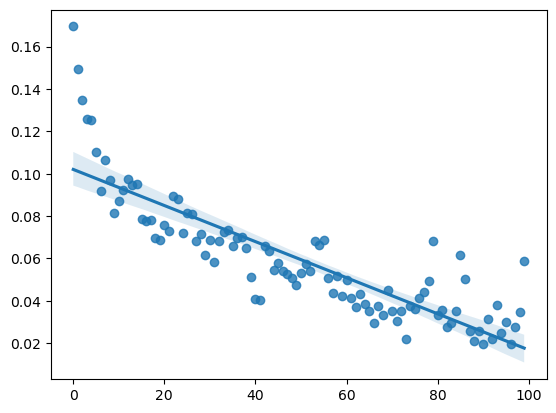

In [105]:
sns.regplot(x=list(range(len(net_losses))), y=net_losses)

In [108]:
from sklearn.metrics import accuracy_score

true = []
predictions = []
for (x, y) in testLoader:
    # print(f'ytrue: {y}')
    true.extend(y)
    with torch.no_grad():
        output = net(x)
        values, preds = torch.max(output, 1)
        predictions.extend(preds)
        # print(f'predictions(indeces): {preds}')
        # print(f'raw output values: {values}')
accuracy_score(true, predictions)



0.6060606060606061

In [ ]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(true, predictions,)

In [113]:
cm

array([[25,  4,  3,  0],
       [ 2, 12,  0,  1],
       [ 2,  8, 15,  2],
       [ 7,  8,  2,  8]])